<a href="https://colab.research.google.com/github/dudu-soliveira/engenharia-software-tp1/blob/main/BurnCheck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação das Bibliotecas

In [ ]:
!pip install lmdiag

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
import statsmodels.formula.api as smf  # <-- Importação essencial para ANOVA
from statsmodels.stats.anova import anova_lm

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from sklearn.compose import TransformedTargetRegressor

import lmdiag

-----
# Importação dos Dados

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sharmajicoder/student-mental-health-and-burnout")

100%|██████████| 131M/131M [00:08<00:00, 17.1MB/s]

Extracting files...


In [ ]:
import os

# 1. Liste os arquivos baixados para descobrir o nome exato do CSV
print(os.listdir(path))

# 2. Carregue o arquivo (substitua 'nome_do_arquivo.csv' pelo nome listado acima)
caminho_arquivo = os.path.join(path, "student_mental_health_burnout_1M.csv")
df = pd.read_csv(caminho_arquivo)

# 3. Visualize os dados
df.head()

['student_mental_health_burnout_1M.csv']


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


----
# EDA



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

### Colunas Textuais

In [ ]:
# Filtra apenas as colunas do tipo object/string e pega os nomes
colunas_texto = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(colunas_texto)

['gender', 'risk_level']


### Matriz de Correlação

<Axes: >

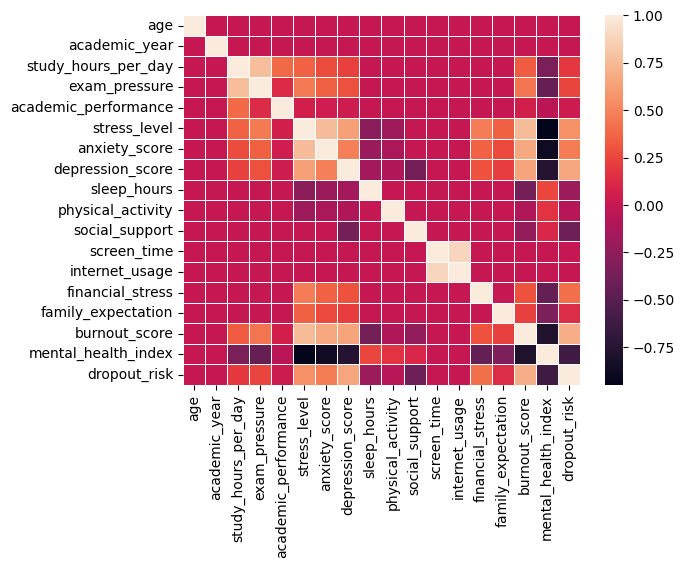

In [ ]:
corrMatrix = df.corr(numeric_only = True)

sns.heatmap(corrMatrix,
            linewidths=0.5)

### Distribuição da Variável Resposta

<Axes: >

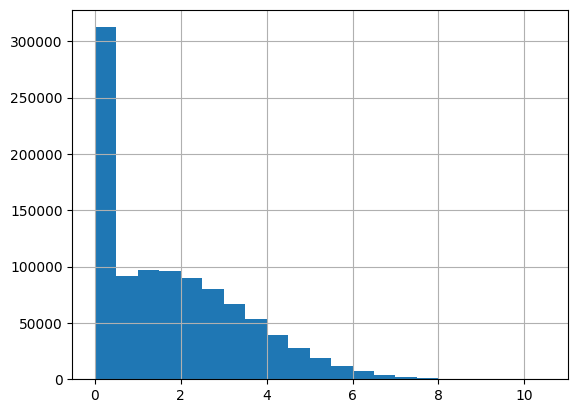

In [ ]:
df['burnout_score'].hist(
    bins = np.arange(0, 11, 0.5)
)

In [ ]:
ln_burn = np.log(df['burnout_score'] + 0.001)

<Axes: >

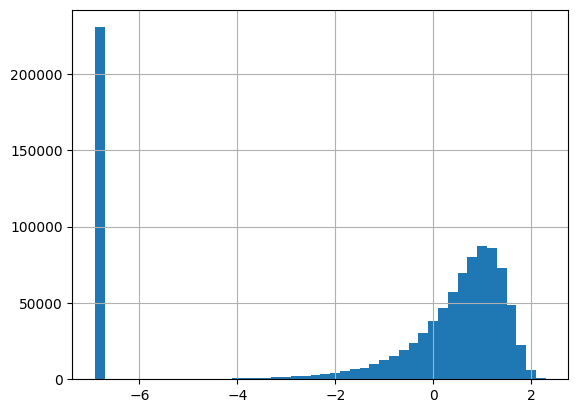

In [ ]:
ln_burn.hist(
    bins = np.arange(ln_burn.min(), ln_burn.max(), 0.2)
)

In [ ]:
df['burnout_score'].describe()

,burnout_score
count,1000000.000000
mean,1.784073
std,1.664035
min,0.000000
25%,0.124810
50%,1.496505
75%,2.889473
max,10.000000


### Exclusão de colunas incoerentes com a proposta

In [ ]:
df = df.drop(columns = ['academic_year', 'mental_health_index', 'risk_level'])

### Distribuição das Variáveis Preditoras

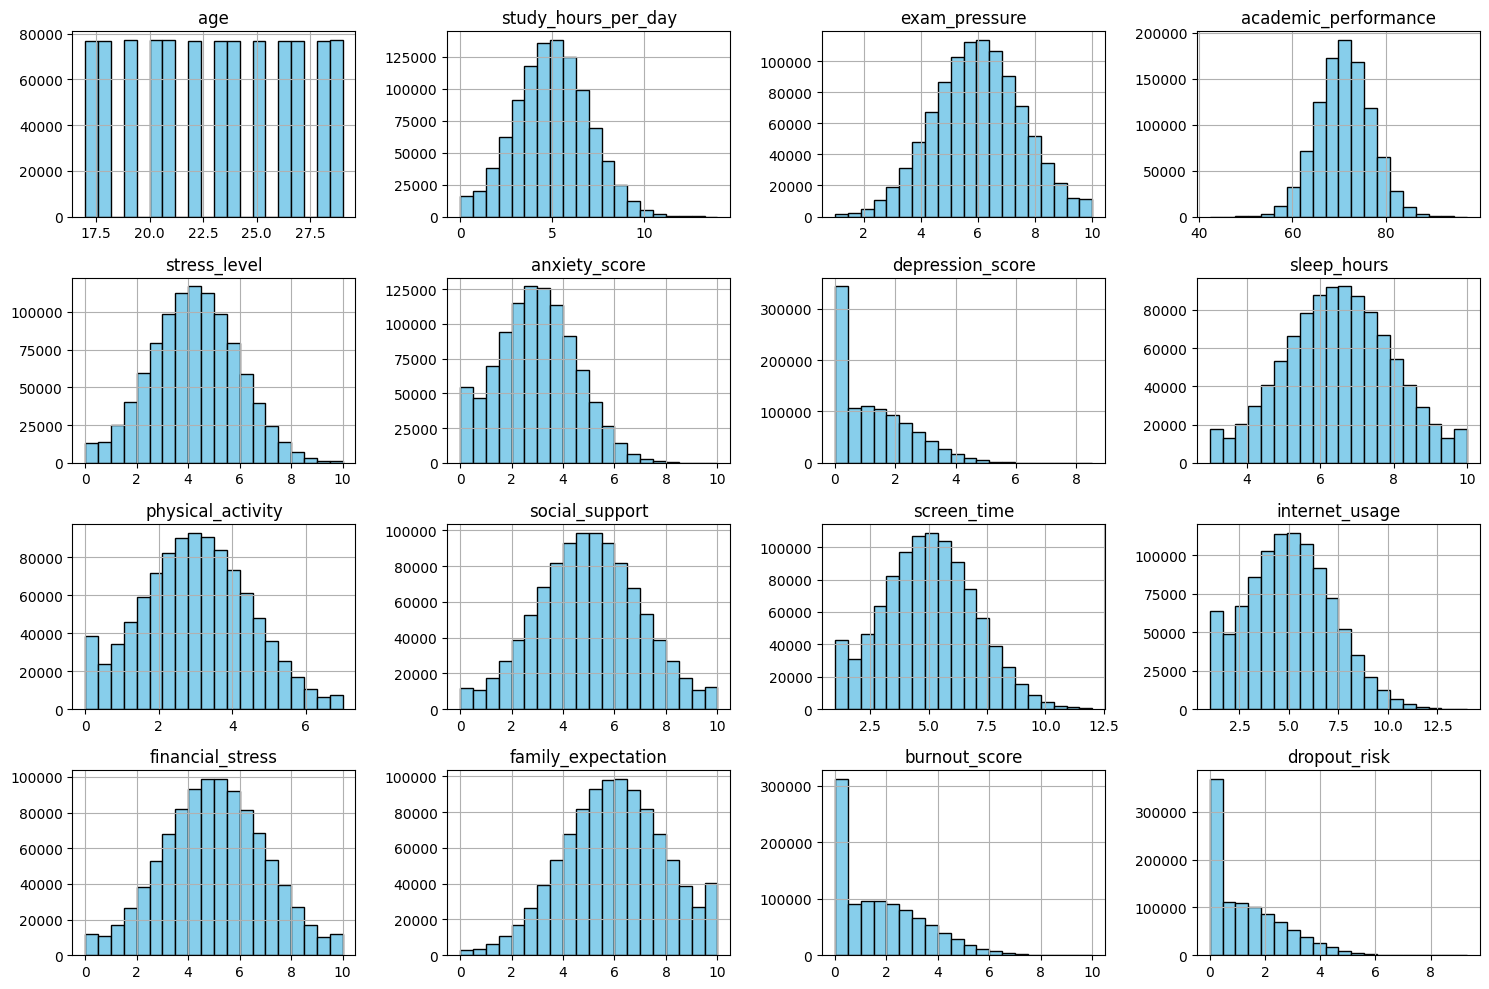

In [ ]:
df_numerico = df.select_dtypes(include=['number'])
df_numerico.hist(bins=20, figsize=(15, 10), edgecolor='black', color='skyblue')

# 4. Ajustar o layout e exibir
plt.tight_layout() # Evita que os títulos dos gráficos se sobreponham
plt.show()

------
# Modelagem

### Criação das colunas Dummy

In [ ]:
colunas_texto = df.select_dtypes(include=['object', 'string']).columns.tolist()
df_dummy = pd.get_dummies(df, columns= colunas_texto, drop_first=True, dtype=int)
df_dummy

,age,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,dropout_risk,gender_Male,gender_Other
0,23,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,1.746601,1,0
1,20,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,0.000000,1,0
2,29,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,0.696941,1,0
3,27,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,5.380592,1,0
4,24,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,0.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,22,5.784771,4.922653,79.292283,2.033221,1.238058,0.000000,8.214062,4.404825,9.013047,1.000000,1.664220,5.374860,4.875184,0.000000,0.000000,0,0
999996,20,3.795347,4.706976,70.718819,4.144918,2.768193,1.405596,6.701671,2.664749,8.678769,2.641657,2.923180,5.100452,5.495558,1.166516,0.000000,1,0
999997,24,8.814898,8.750319,79.121184,4.715533,4.138000,1.931592,6.569535,4.219224,4.881412,5.224459,3.855320,2.290888,6.792472,1.997088,1.172209,0,0
999998,29,5.920859,6.678223,69.424255,5.553155,5.681447,1.366879,8.017232,3.634823,5.232852,2.668379,2.951508,5.885972,6.829679,2.731137,1.968401,0,0


In [ ]:
y = np.array((df_dummy['burnout_score']))
X = np.array(df_dummy.drop(columns = 'burnout_score'))

X = sm.add_constant(X)

### Estimação do Modelo de Regressão Linear Múltipla: Com Intercepto

In [ ]:
model = sm.OLS(y, X).fit()

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                 1.737e+05
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:47:57   Log-Likelihood:            -1.2409e+06
No. Observations:             1000000   AIC:                         2.482e+06
Df Residuals:                  999982   BIC:                         2.482e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3223      0.015     22.034      0.000       0.294       0.351
x1            -0.0001      0.000     -0.610      0.542      -0.001       0.000
x2             0.0024      0.001      3.203      0.001       0.001       0.004
x3             0.1314      0.001    134.918      0.000       0.129       0.133
x4         -2.943e-05      0.000     -0.176      0.861      -0.000       0.000
x5             0.3102      0.001    276.576      0.000       0.308       0.312
x6             0.2164      0.001    252.238      0.000       0.215       0.218
x7             0.1112      0.001    105.709      0.000       0.109       0.113
x8            -0.2007      0.001   -320.766      0.000      -0.202      -0.199
x9             0.0010      0.001      1.680      0.093      -0.000       0.002
x10           -0.0671      0.001   -131.865      0.000      -0.068      -0.066
x11           -0.0022      0.001     -2.316      0.021      -0.004      -0.000
x12            0.0016      0.001      1.927      0.054   -2.82e-05       0.003
x13           -0.0570      0.001   -102.386      0.000      -0.058      -0.056
x14           -0.0022      0.000     -4.379      0.000      -0.003      -0.001
x15            0.3774      0.001    402.129      0.000       0.376       0.379
x16         4.532e-05      0.002      0.027      0.979      -0.003       0.003
x17            0.0044      0.004      1.013      0.311      -0.004       0.013
==============================================================================
Omnibus:                     5197.008   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5331.180
Skew:                           0.168   Prob(JB):                         0.00
Kurtosis:                       3.122   Cond. No.                     1.34e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
alvo = 'burnout_score'

# 4. Gerar os preditores automaticamente
preditores = []
for coluna in df.columns:
    if coluna != alvo:
        # Se a coluna for de texto ('object') ou 'category', adicionamos o C()
        if df[coluna].dtype == 'object' or df[coluna].dtype.name == 'category':
            preditores.append(f'C({coluna})')
        else:
            preditores.append(coluna)

# 5. Unir tudo com o sinal de soma
formula = f"{alvo} ~ " + " + ".join(preditores)

print("Sua fórmula gerada é:")
print(formula)

Sua fórmula gerada é:
burnout_score ~ age + C(gender) + study_hours_per_day + exam_pressure + academic_performance + stress_level + anxiety_score + depression_score + sleep_hours + physical_activity + social_support + screen_time + internet_usage + financial_stress + family_expectation + dropout_risk


In [ ]:
modelo = smf.ols(formula = formula, data = df).fit()
anova = sm.stats.anova_lm(modelo, typ = 2)
anova

,sum_sq,df,F,PR(>F)
C(gender),0.740725,2.0,0.528733,0.589351
age,0.260460,1.0,0.371836,0.542005
study_hours_per_day,7.185998,1.0,10.258800,0.001360
exam_pressure,12750.653986,1.0,18202.955963,0.000000
academic_performance,0.021602,1.0,0.030840,0.860599
stress_level,53582.222090,1.0,76494.494333,0.000000
anxiety_score,44566.817103,1.0,63624.015678,0.000000
depression_score,7827.322901,1.0,11174.361270,0.000000
sleep_hours,72071.957547,1.0,102890.618064,0.000000
physical_activity,1.976752,1.0,2.822030,0.092979


In [ ]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          burnout_score   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                 1.737e+05
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:48:01   Log-Likelihood:            -1.2409e+06
No. Observations:             1000000   AIC:                         2.482e+06
Df Residuals:                  999982   BIC:                         2.482e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3223      0.015     22.034      0.000       0.294       0.351
C(gender)[T.Male]     4.532e-05      0.002      0.027      0.979      -0.003       0.003
C(gender)[T.Other]       0.0044      0.004      1.013      0.311      -0.004       0.013
age                     -0.0001      0.000     -0.610      0.542      -0.001       0.000
study_hours_per_day      0.0024      0.001      3.203      0.001       0.001       0.004
exam_pressure            0.1314      0.001    134.918      0.000       0.129       0.133
academic_performance -2.943e-05      0.000     -0.176      0.861      -0.000       0.000
stress_level             0.3102      0.001    276.576      0.000       0.308       0.312
anxiety_score            0.2164      0.001    252.238      0.000       0.215       0.218
depression_score         0.1112      0.001    105.709      0.000       0.109       0.113
sleep_hours             -0.2007      0.001   -320.766      0.000      -0.202      -0.199
physical_activity        0.0010      0.001      1.680      0.093      -0.000       0.002
social_support          -0.0671      0.001   -131.865      0.000      -0.068      -0.066
screen_time             -0.0022      0.001     -2.316      0.021      -0.004      -0.000
internet_usage           0.0016      0.001      1.927      0.054   -2.82e-05       0.003
financial_stress        -0.0570      0.001   -102.386      0.000      -0.058      -0.056
family_expectation      -0.0022      0.000     -4.379      0.000      -0.003      -0.001
dropout_risk             0.3774      0.001    402.129      0.000       0.376       0.379
==============================================================================
Omnibus:                     5197.008   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5331.180
Skew:                           0.168   Prob(JB):                         0.00
Kurtosis:                       3.122   Cond. No.                     1.34e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

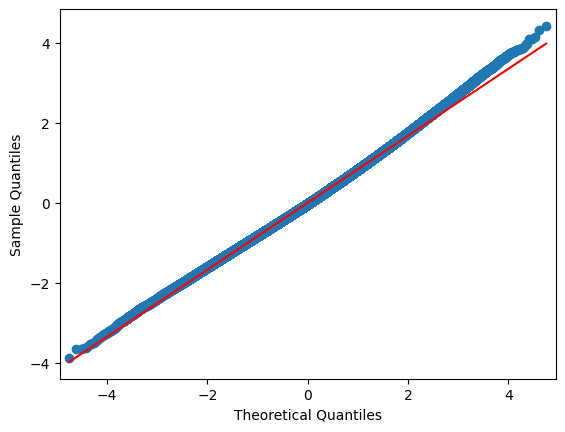

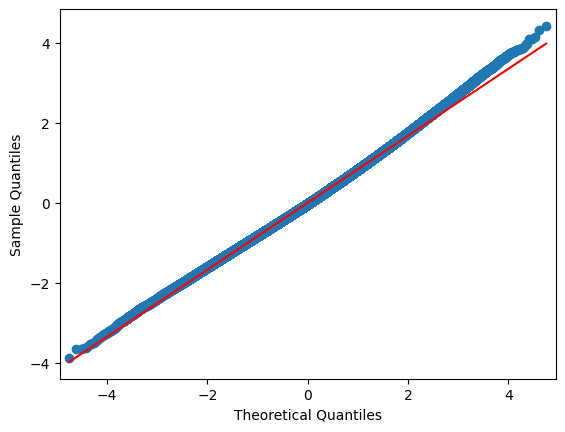

In [ ]:
sm.qqplot(modelo.resid, line = 's')

---

# LASSO



In [ ]:
X = df_dummy.drop(columns = 'burnout_score')
y = df_dummy['burnout_score']

# 2. Dividir em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. CRUCIAL: Padronizar os dados (Média 0 e Desvio Padrão 1)
# Atenção: Ajustamos o scaler APENAS no treino, e depois transformamos o teste
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Ajustar o Modelo LASSO com Validação Cruzada (Cross-Validation)
# cv=5 significa que ele vai testar o rigor matemático 5 vezes para achar o melhor
modelo_lasso = LassoCV(cv=5, random_state=42)
modelo_lasso.fit(X_train_scaled, y_train)

print(f"O melhor nível de penalidade (Alpha) encontrado foi: {modelo_lasso.alpha_:.4f}")

O melhor nível de penalidade (Alpha) encontrado foi: 0.0013


In [ ]:
# 5. Avaliar o modelo
previsoes = modelo_lasso.predict(X_test_scaled)
print(f"R² do modelo LASSO: {r2_score(y_test, previsoes):.4f}")

R² do modelo LASSO: 0.7473


In [ ]:
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_lasso.coef_
})

In [ ]:
coeficientes

,Variável,Coeficiente
0,age,-0.000000
1,study_hours_per_day,0.005208
2,exam_pressure,0.203774
3,academic_performance,0.000000
4,stress_level,0.516954
5,anxiety_score,0.325862
6,depression_score,0.135680
7,sleep_hours,-0.295517
8,physical_activity,0.000000
9,social_support,-0.131287


In [ ]:
coeficientes.sort_values(by = 'Coeficiente', key=lambda x: x.abs(), ascending = False).head()

,Variável,Coeficiente
4,stress_level,0.516954
14,dropout_risk,0.506723
5,anxiety_score,0.325862
7,sleep_hours,-0.295517
2,exam_pressure,0.203774


In [ ]:
coefsRelevantes = coeficientes[coeficientes['Coeficiente'] != 0]['Variável'].tolist()

In [ ]:
df_lasso = df_dummy[coefsRelevantes]

In [ ]:
df_lasso

,study_hours_per_day,exam_pressure,stress_level,anxiety_score,depression_score,sleep_hours,social_support,financial_stress,family_expectation,dropout_risk
0,5.596071,6.487218,4.116950,2.275713,1.986730,6.880545,6.470080,3.446626,3.586147,1.746601
1,5.597171,5.631481,0.349489,0.000000,0.000000,7.463339,0.000000,2.814039,5.478666,0.000000
2,2.580491,6.015297,3.476177,2.425201,0.851996,8.946670,6.901725,4.918515,6.068155,0.696941
3,4.607208,6.684005,6.778843,4.512425,4.285645,4.571380,2.349857,6.915885,6.557540,5.380592
4,2.186569,4.010945,1.854595,1.102558,0.000000,5.989324,4.512921,4.382820,5.934779,0.000000
...,...,...,...,...,...,...,...,...,...,...
999995,5.784771,4.922653,2.033221,1.238058,0.000000,8.214062,9.013047,5.374860,4.875184,0.000000
999996,3.795347,4.706976,4.144918,2.768193,1.405596,6.701671,8.678769,5.100452,5.495558,0.000000
999997,8.814898,8.750319,4.715533,4.138000,1.931592,6.569535,4.881412,2.290888,6.792472,1.172209
999998,5.920859,6.678223,5.553155,5.681447,1.366879,8.017232,5.232852,5.885972,6.829679,1.968401


In [ ]:
X_lasso = df_lasso
y_lasso = df_dummy['burnout_score']

X_lasso = sm.add_constant(X_lasso)

In [ ]:
model_lasso = sm.OLS(y_lasso, X_lasso).fit()

In [ ]:
model_lasso.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          burnout_score   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                 2.953e+05
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:48:09   Log-Likelihood:            -1.2409e+06
No. Observations:             1000000   AIC:                         2.482e+06
Df Residuals:                  999989   BIC:                         2.482e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3175      0.006     49.301      0.000       0.305       0.330
study_hours_per_day     0.0023      0.001      3.510      0.000       0.001       0.004
exam_pressure           0.1316      0.001    141.125      0.000       0.130       0.133
stress_level            0.3098      0.001    282.652      0.000       0.308       0.312
anxiety_score           0.2164      0.001    252.240      0.000       0.215       0.218
depression_score        0.1112      0.001    105.709      0.000       0.109       0.113
sleep_hours            -0.2008      0.001   -323.053      0.000      -0.202      -0.200
social_support         -0.0671      0.001   -131.861      0.000      -0.068      -0.066
financial_stress       -0.0569      0.001   -103.586      0.000      -0.058      -0.056
family_expectation     -0.0020      0.000     -4.178      0.000      -0.003      -0.001
dropout_risk            0.3774      0.001    402.132      0.000       0.376       0.379
==============================================================================
Omnibus:                     5197.862   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5332.073
Skew:                           0.168   Prob(JB):                         0.00
Kurtosis:                       3.123   Cond. No.                         116.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
yHat = model_lasso.predict(X_lasso)
yHat = np.clip(yHat, 0, 10)

error = y - yHat

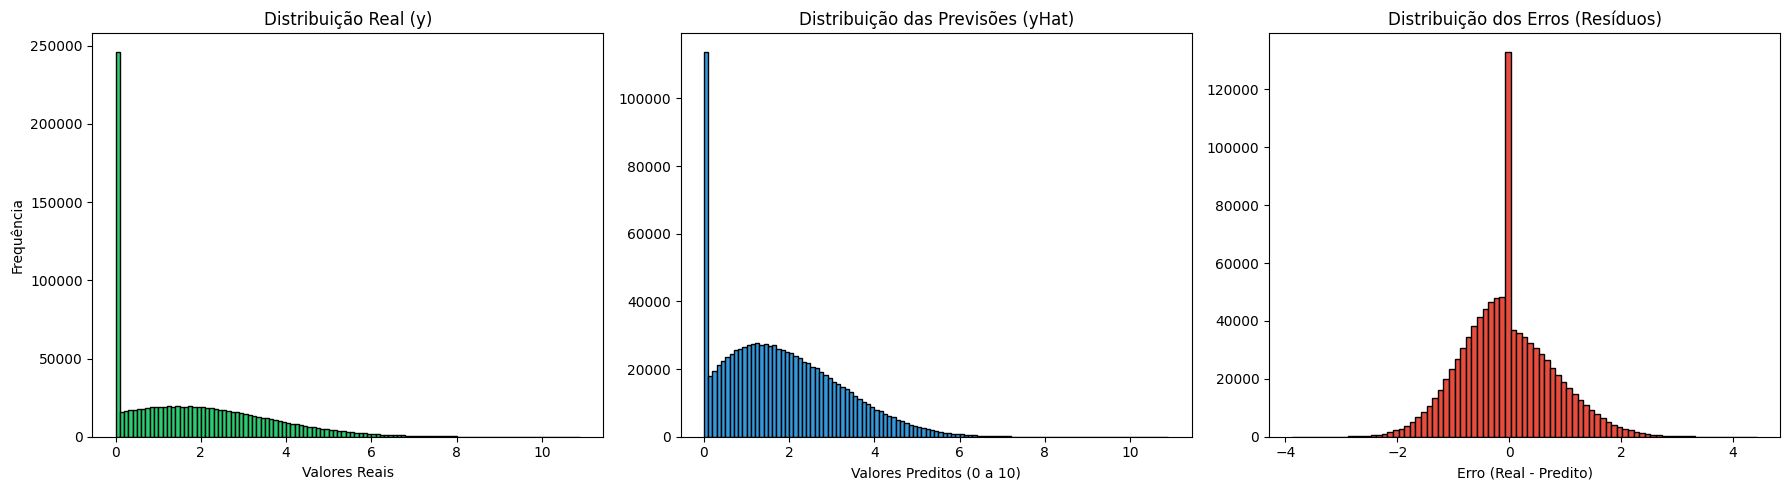

In [ ]:
# Cria uma figura com 1 linha e 3 colunas (ax1, ax2 e ax3)
# Aumentei o tamanho da largura (figsize) para acomodar o terceiro gráfico
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

esp = 0.1

# ==========================================
# Gráfico 1: Valores Reais (y)
# ==========================================
# Presumo que o seu 'y' varie entre 0 e 10. Se a escala for outra,
# pode remover o argumento 'bins' e deixar o matplotlib escolher automaticamente
ax1.hist(y, bins=np.arange(0, 11, esp), color='#2ecc71', edgecolor='black')
ax1.set_title('Distribuição Real (y)')
ax1.set_xlabel('Valores Reais')
ax1.set_ylabel('Frequência')

# ==========================================
# Gráfico 2: Previsões (yHat)
# ==========================================
ax2.hist(yHat, bins=np.arange(0, 11, esp), color='#3498db', edgecolor='black')
ax2.set_title('Distribuição das Previsões (yHat)')
ax2.set_xlabel('Valores Preditos (0 a 10)')

# ==========================================
# Gráfico 3: Erros (Resíduos)
# ==========================================
limite_max_erro = error.max() + esp
ax3.hist(error, bins=np.arange(error.min(), limite_max_erro, esp), color='#e74c3c', edgecolor='black')
ax3.set_title('Distribuição dos Erros (Resíduos)')
ax3.set_xlabel('Erro (Real - Predito)')

# Ajusta o espaçamento para não sobrepor os textos
plt.tight_layout()

# Exibe o painel completo
plt.show()

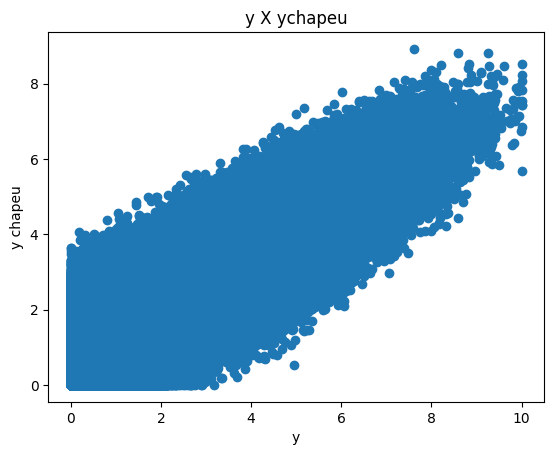

In [ ]:
plt.scatter(y, yHat)
plt.title("y X ychapeu")
plt.xlabel("y")
plt.ylabel("y chapeu")
plt.show()


In [ ]:
r2 = r2_score(y, yHat)
r2

0.7603097189417992

In [ ]:
yClass = y.round().astype(int)
yHatClass = np.floor(yHat).astype(int)
equal = 0
for i in range(len(yClass)):
  if yClass[i] == yHatClass[i]:
    equal = equal + 1

precision = equal/len(yClass)


In [ ]:
precision

0.482891

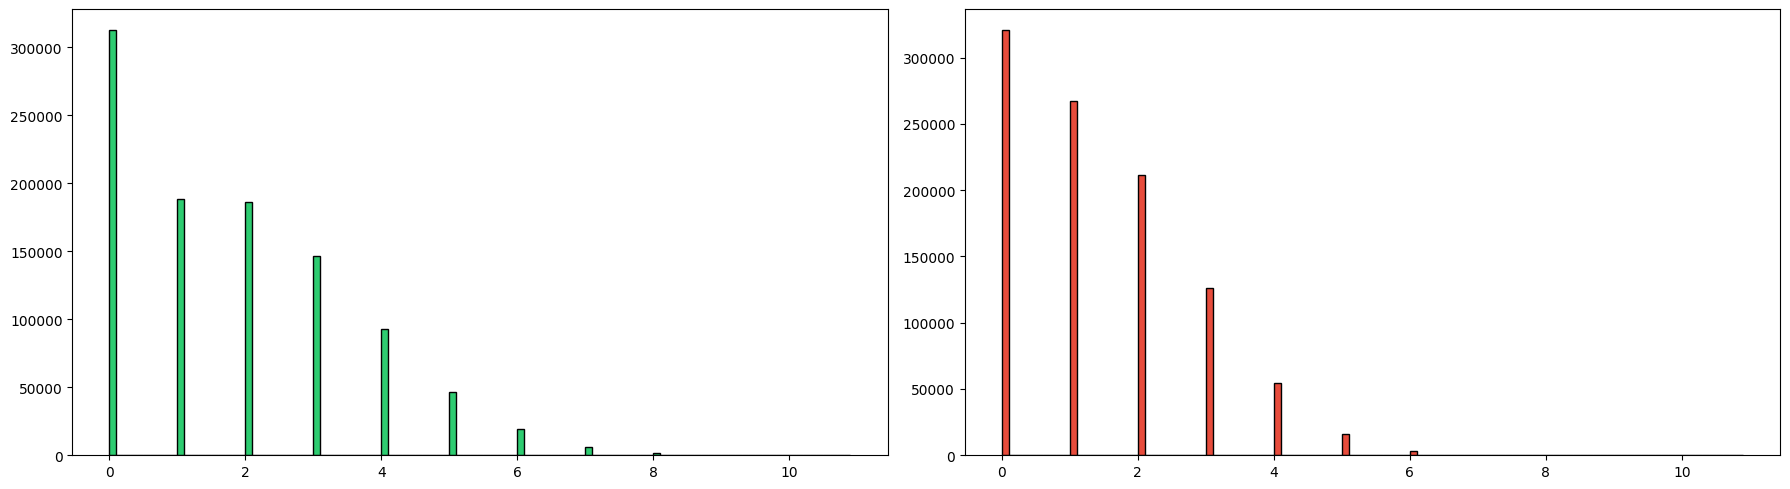

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1.hist(yClass, bins=np.arange(0, 11, esp), color='#2ecc71', edgecolor='black')

ax2.hist(yHatClass, bins=np.arange(0, 11, esp), color='#e74c3c', edgecolor='black')

# Ajusta o espaçamento para não sobrepor os textos
plt.tight_layout()

# Exibe o painel completo
plt.show()

---
# Métodos de Classificação


In [ ]:
df

,age,gender,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,dropout_risk
0,23,Male,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,1.746601
1,20,Male,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,0.000000
2,29,Male,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,0.696941
3,27,Male,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,5.380592
4,24,Male,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,22,Female,5.784771,4.922653,79.292283,2.033221,1.238058,0.000000,8.214062,4.404825,9.013047,1.000000,1.664220,5.374860,4.875184,0.000000,0.000000
999996,20,Male,3.795347,4.706976,70.718819,4.144918,2.768193,1.405596,6.701671,2.664749,8.678769,2.641657,2.923180,5.100452,5.495558,1.166516,0.000000
999997,24,Female,8.814898,8.750319,79.121184,4.715533,4.138000,1.931592,6.569535,4.219224,4.881412,5.224459,3.855320,2.290888,6.792472,1.997088,1.172209
999998,29,Female,5.920859,6.678223,69.424255,5.553155,5.681447,1.366879,8.017232,3.634823,5.232852,2.668379,2.951508,5.885972,6.829679,2.731137,1.968401


In [ ]:
def burn_level(score):
  level = 'n'
  if score < 3:
    level = 'low'
  elif score >= 7:
    level = 'high'
  else:
    level = 'medium'
  return level


In [ ]:
df['burn_level'] = df['burnout_score'].apply(
    burn_level
    )

In [ ]:
df

,age,gender,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,dropout_risk,burn_level
0,23,Male,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,1.746601,low
1,20,Male,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,0.000000,low
2,29,Male,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,0.696941,low
3,27,Male,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,5.380592,high
4,24,Male,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,0.000000,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,22,Female,5.784771,4.922653,79.292283,2.033221,1.238058,0.000000,8.214062,4.404825,9.013047,1.000000,1.664220,5.374860,4.875184,0.000000,0.000000,low
999996,20,Male,3.795347,4.706976,70.718819,4.144918,2.768193,1.405596,6.701671,2.664749,8.678769,2.641657,2.923180,5.100452,5.495558,1.166516,0.000000,low
999997,24,Female,8.814898,8.750319,79.121184,4.715533,4.138000,1.931592,6.569535,4.219224,4.881412,5.224459,3.855320,2.290888,6.792472,1.997088,1.172209,low
999998,29,Female,5.920859,6.678223,69.424255,5.553155,5.681447,1.366879,8.017232,3.634823,5.232852,2.668379,2.951508,5.885972,6.829679,2.731137,1.968401,low
